In [1]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('..'))

In [2]:
# configura per importare da src
import sys
sys.path.append('./src')

## Box creation

### Load dataset

In [3]:
import re

concepts_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/extended_concepts.txt'
def parse_concepts(filepath):
    """Legge il file dei concetti e restituisce una lista ordinata."""
    concepts = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome del concetto
            if len(parts) >= 2:
                concepts.append(parts[1])
    return concepts
concepts = parse_concepts(concepts_file)

In [4]:
import re

classes_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/classes.txt'
def parse_classes(filepath):
    """Legge il file delle classi e restituisce una lista ordinata."""
    classes = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome della classe
            if len(parts) >= 2:
                classes.append(parts[1])
    return classes

classes = parse_classes(classes_file)

In [5]:
import torch
from src.utils.dataset import classical_split_awa2_features
import numpy as np

features_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-features.txt'
labels_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-labels.txt'

(X_train, y_train), (X_val, y_val), (X_test, y_test) = classical_split_awa2_features(
    features_path, labels_path, test_size=0.2, val_size=0.1, random_seed=42
)
class_concept_matrix = torch.from_numpy(np.loadtxt('../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))

Caricamento dei dati in corso... (potrebbe richiedere qualche secondo)
Dataset caricato correttamente: 37322 campioni con 2048 feature ciascuno.

--- Risultati dello Split Stratificato (50 Classi) ---
Training set:   26124 campioni
Validation set: 3733 campioni
Test set:       7465 campioni


In [6]:
from src.utils.box import compute_concept_implications
concept_implications = compute_concept_implications(y_train, class_concept_matrix)
concept_implications = torch.clamp(concept_implications, min=0.0, max=1.0)

AllenNLP not available. Registrable won't work.


In [7]:
import json

JSON_PATH='../AwA2_Dataset_Labels/Animals_with_Attributes2/supervisioni_gerarchia.json'
def load_data(json_path, concepts):
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    concept2id = {c: idx for idx, c in enumerate(concepts)}
    id2concept = {idx: c for c, idx in concept2id.items()}
    
    # Prepariamo il dataset nel formato [(id_i, id_j, label), ...]
    dataset = []
    for item in data:
        dataset.append((concept2id[item[0]], concept2id[item[1]], float(item[2])))
        
    return dataset, concept2id, id2concept

In [8]:
dataset, concept2id, id2concept = load_data(JSON_PATH, concepts)

### Train

In [9]:
from src.CHM.model import BoxHierarchyModel
from src.CHM.train import train_box_empirical
import torch.nn as nn
from torch.optim import Adam

LR = 0.05

box_model = BoxHierarchyModel(num_concepts=concept_implications.shape[0], dim=5)
optimizer = Adam(box_model.parameters(), lr=LR)
criterion = nn.BCELoss() # Binary Cross Entropy

In [10]:
box_model = train_box_empirical(
    box_model, 
    concept_implications, 
    optimizer, 
    criterion,
    epochs=50,
)

Epoch 1/50 | Loss: 0.5564
Epoch 10/50 | Loss: 0.4548
Epoch 20/50 | Loss: 0.4467
Epoch 30/50 | Loss: 0.4350
Epoch 40/50 | Loss: 0.4348
Epoch 50/50 | Loss: 0.4490
Addestramento completato!


### Visualization

In [11]:
from src.CHM.visualization import visualize_concept_hierarchy, visualize_heatmap_compare, visualize_all_boxes_2d

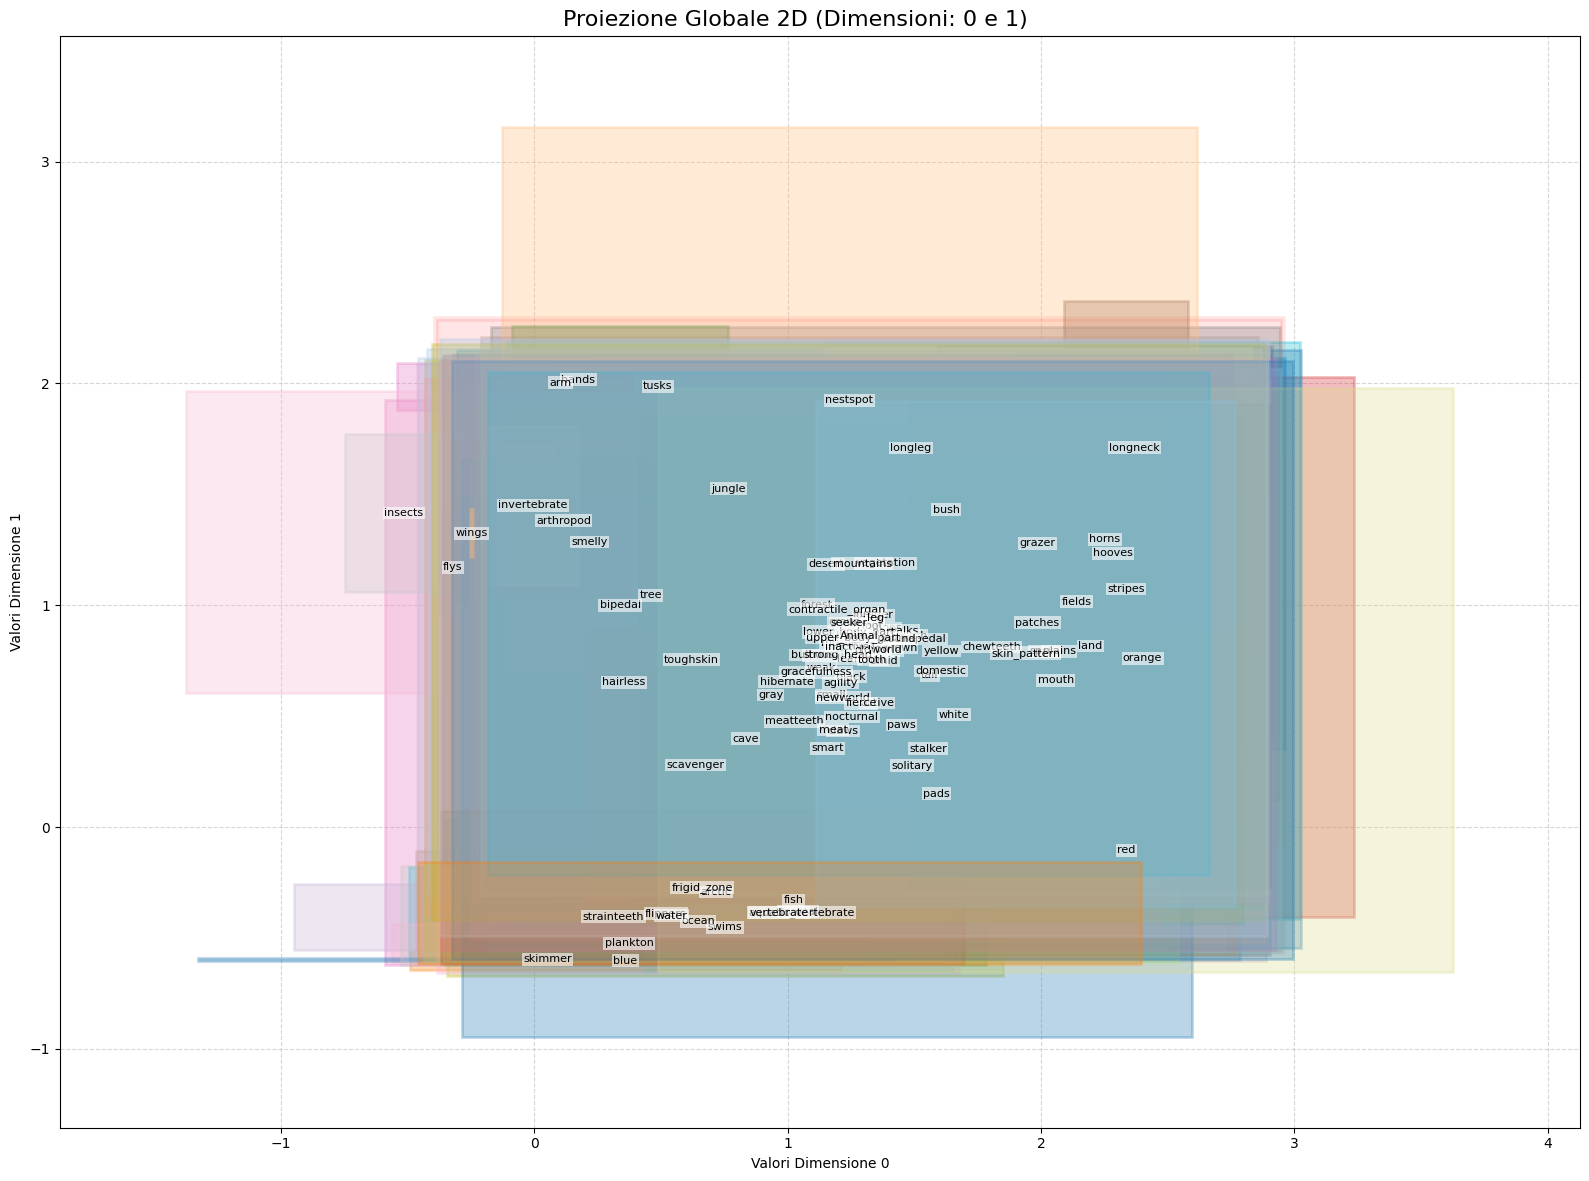

In [12]:
# cambiare dim_x e dim_y (da 0 a 31) per esplorare la "forma" da diverse angolazioni
visualize_all_boxes_2d(box_model, id2concept, dim_x=0, dim_y=1)

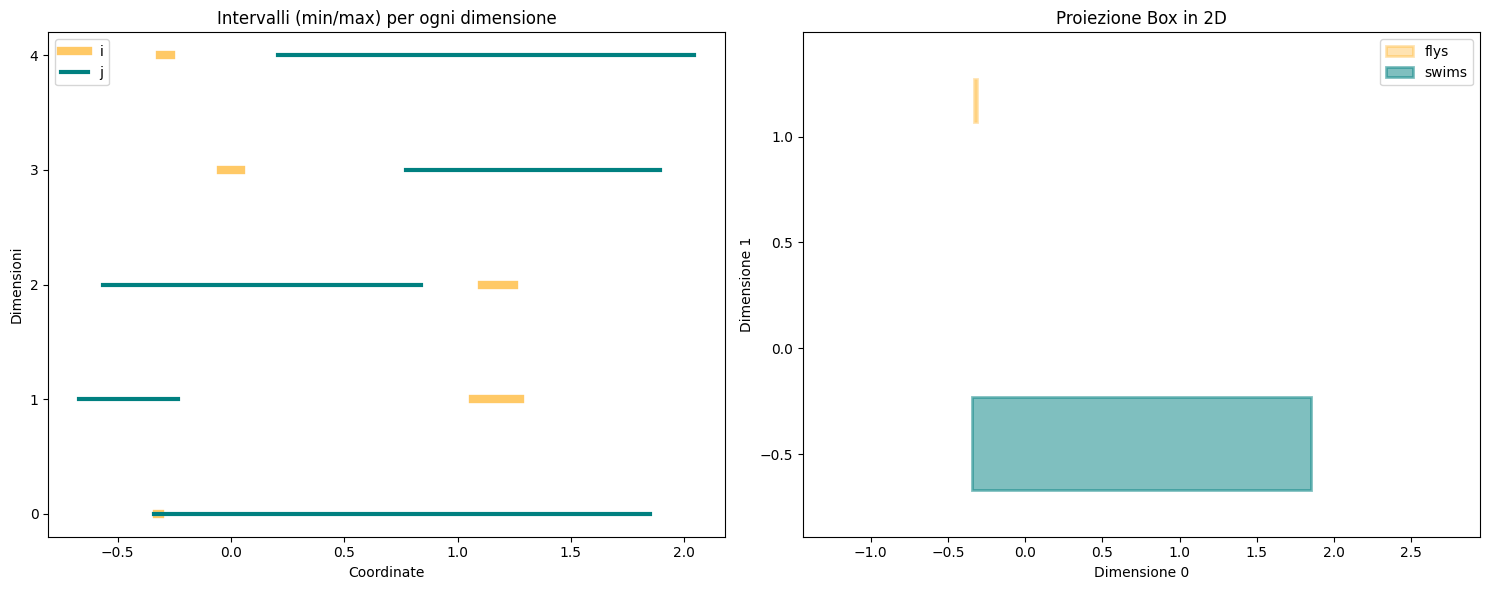

In [13]:
visualize_concept_hierarchy(box_model, id2concept, concept2id, "flys", "swims")

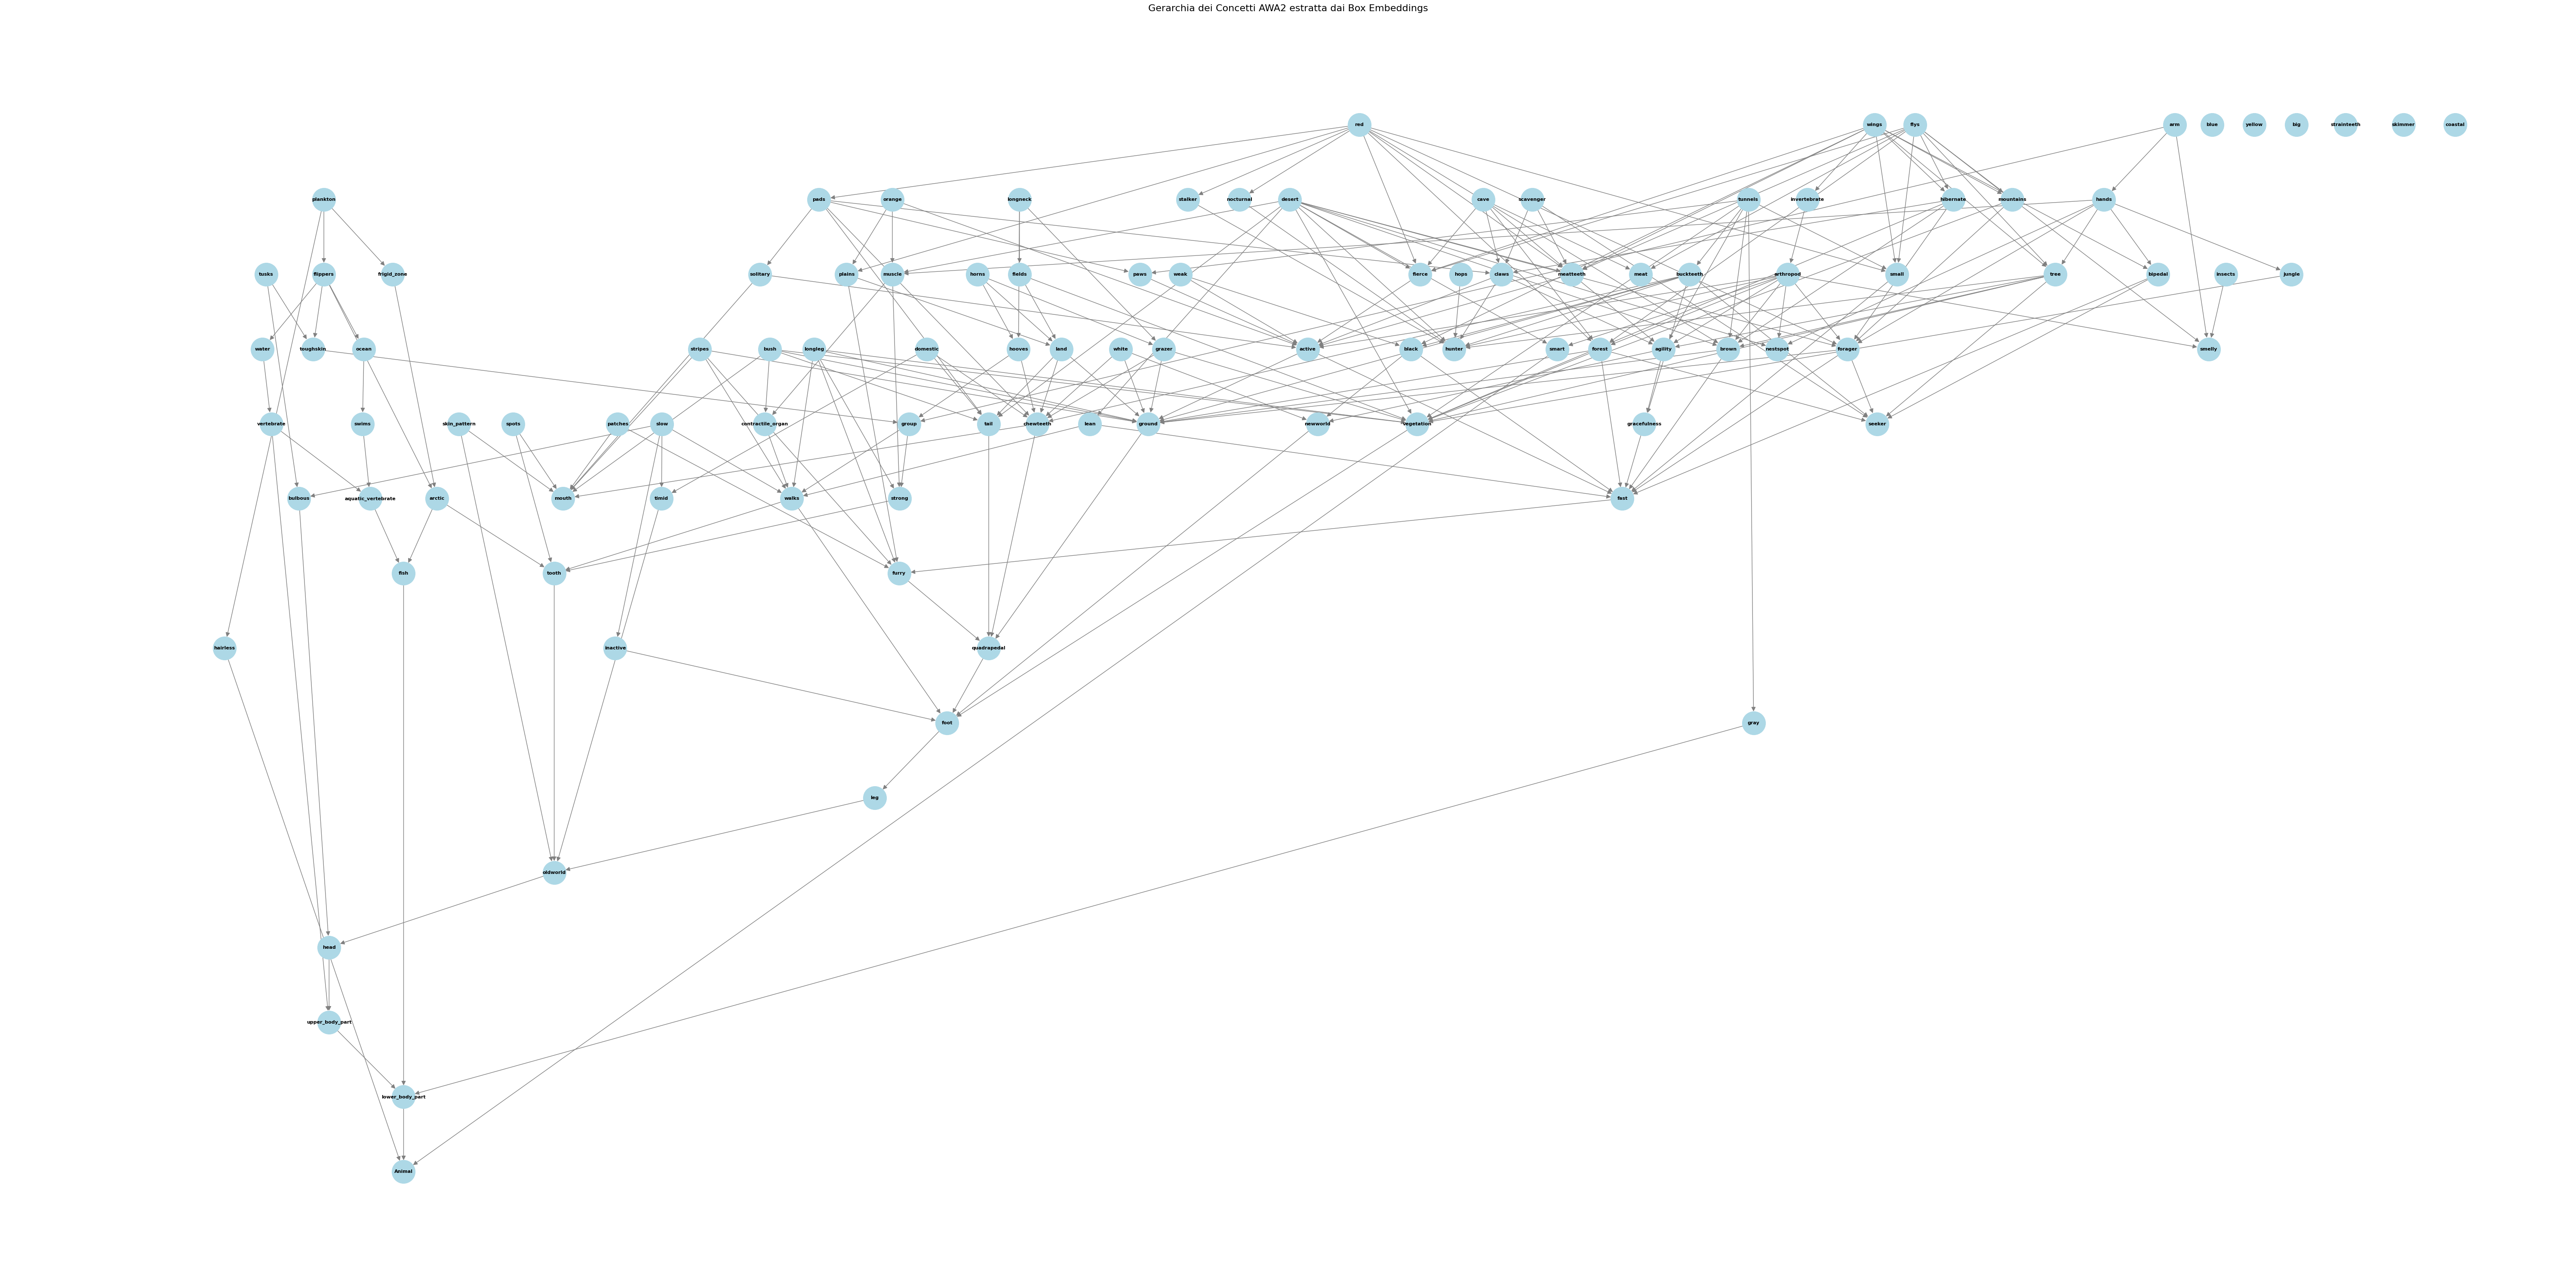

In [14]:
from src.utils.box import extract_hierarchy
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import pydot_layout

plt.figure(figsize=(60, 30))


hierarchy_graph = extract_hierarchy(box_model, num_concepts=len(concepts), concept_names=concepts)
pos = pydot_layout(hierarchy_graph, prog="dot")

nx.draw_networkx(
     hierarchy_graph, 
     labels=nx.get_node_attributes(hierarchy_graph, 'label'),
     node_size=1500, 
     node_color="lightblue", 
     font_size=8,
     pos=pos,
     font_weight="bold",
     edge_color="gray",
     arrows=True,
     arrowsize=15,       # Frecce ben visibili per indicare la direzione
     arrowstyle="-|>"
)
plt.title("Gerarchia dei Concetti AWA2 estratta dai Box Embeddings", fontsize=16)
plt.axis("off") # Rimuove il bordo e le coordinate dal grafico
plt.tight_layout()
plt.show()

### Save boxes

In [15]:
from src.utils.box import get_box_dict

box_dict = get_box_dict(box_model, id2concept)

## CBM

### Load dataset

In [16]:
import torch
torch.save(box_model.state_dict(), "modello_gerarchia.pth")

In [17]:
box_model.load_state_dict(torch.load("modello_gerarchia.pth"))

<All keys matched successfully>

In [18]:
from src.utils.box import get_box_dict
box_dict = get_box_dict(box_model, id2concept)

In [19]:
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from src.utils.box import prepara_tensore_box

box_tensors = prepara_tensore_box(box_dict, concept2id)

BOX_DIM = 32
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = len(set(y_train))
NUM_CONCEPTS = len(concept2id)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dataset = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long())
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataset = TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val).long())
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, pin_memory=True)
test_dataset = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).long())
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, pin_memory=True)

Using device: cpu


In [20]:
from src.CHM.model import ConceptBottleneckClassifier
from src.CHM.train import train_cbm_classifier
import matplotlib.pyplot as plt
from src.CHM.test import test_cbm_classifier
from src.utils.plot import plot_test_results, plot_concept_error_heatmap, analyze_misclassifications_concepts, plot_concept_uncertainty_heatmap

### CBM with boxes

#### Train

In [21]:
b_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS)
optimizer = torch.optim.Adam(b_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

info = "boxes"

b_history = train_cbm_classifier(
    b_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device
)

Inizio addestramento del classificatore (c -> y)...
Epoca   2/20 | TRAIN: Loss=0.082, Acc=98.8% | VAL: Loss=0.002, Acc=100.0%
Epoca   3/20 | TRAIN: Loss=0.001, Acc=100.0% | VAL: Loss=0.001, Acc=100.0%
Epoca   4/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   5/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   6/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   7/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   8/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   9/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  10/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  11/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  12/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  13/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  14/20 | TRAIN: Loss=0.000, Acc=100.0% | VA

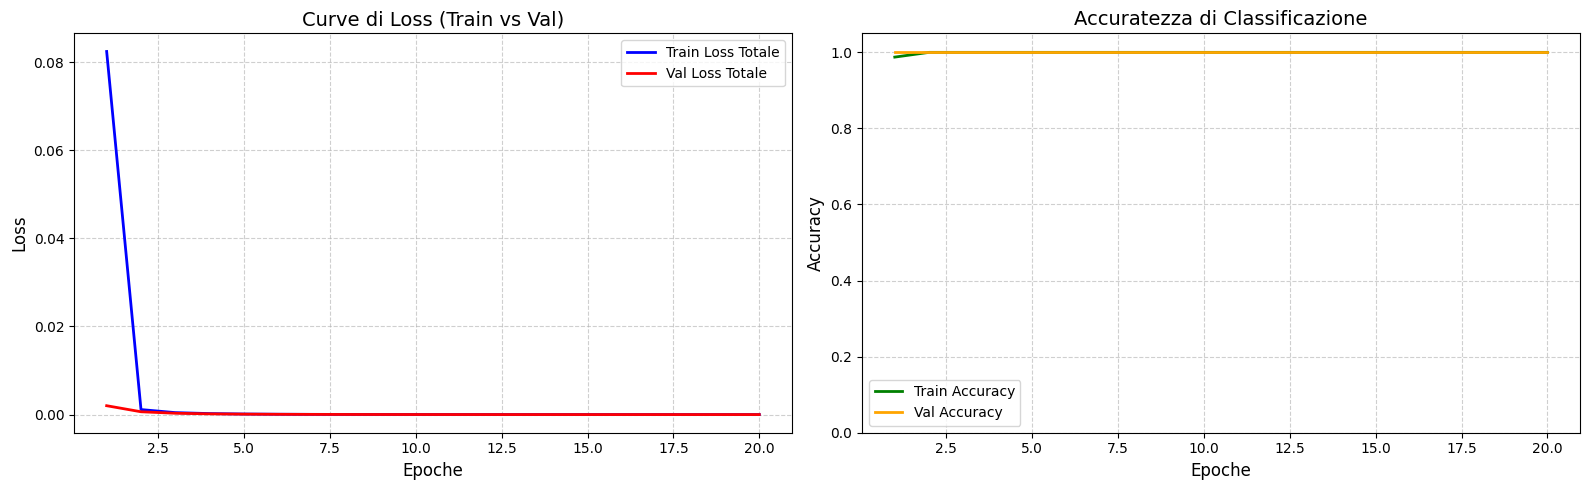

In [22]:
from src.utils.plot import plot_history
plot_history(b_history)

#### Test

In [23]:
accuracy, preds, labels, _, _, _ = test_cbm_classifier(
     model=b_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     oracle=True,
     device="cuda" if torch.cuda.is_available() else "cpu"
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 100.00%


In [ ]:
plot_test_results(accuracy, preds, labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(b_model, test_dataloader, concepts, classes, class_concept_matrix, box_tensors, target_class="chihuahua")

### CBM with cond prob distrib

#### Train

In [33]:
info = "rel_matrix"
bipolar = True
cp_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
optimizer = torch.optim.Adam(cp_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
cp_history = train_cbm_classifier(
    cp_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device,
    info=info,
    bipolar=bipolar
)

Inizio addestramento del classificatore (c -> y)...
Epoca   2/20 | TRAIN: Loss=0.020, Acc=99.6% | VAL: Loss=0.000, Acc=100.0%
Epoca   3/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   4/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   5/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   6/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   7/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   8/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   9/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  10/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  11/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  12/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  13/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  14/20 | TRAIN: Loss=0.000, Acc=100.0% | VA

In [ ]:
from src.utils.plot import plot_history
plot_history(cp_history)

#### Test

In [34]:
cp_accuracy, cp_preds, cp_labels, _, _, _ = test_cbm_classifier(
     model=cp_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=bipolar,
     oracle=True,
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 100.00%


In [ ]:
plot_test_results(accuracy, preds, labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    cp_model, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors, 
    info_type=info, 
    target_class="chihuahua", 
    bipolar=bipolar
)

### CBM standard

In [24]:
info = "concepts"
c_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
optimizer = torch.optim.Adam(c_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
c_history = train_cbm_classifier(
    c_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device,
    info=info
)

Inizio addestramento del classificatore (c -> y)...
Epoca   2/20 | TRAIN: Loss=0.738, Acc=92.9% | VAL: Loss=0.083, Acc=100.0%
Epoca   3/20 | TRAIN: Loss=0.045, Acc=100.0% | VAL: Loss=0.024, Acc=100.0%
Epoca   4/20 | TRAIN: Loss=0.016, Acc=100.0% | VAL: Loss=0.011, Acc=100.0%
Epoca   5/20 | TRAIN: Loss=0.008, Acc=100.0% | VAL: Loss=0.006, Acc=100.0%
Epoca   6/20 | TRAIN: Loss=0.005, Acc=100.0% | VAL: Loss=0.004, Acc=100.0%
Epoca   7/20 | TRAIN: Loss=0.003, Acc=100.0% | VAL: Loss=0.002, Acc=100.0%
Epoca   8/20 | TRAIN: Loss=0.002, Acc=100.0% | VAL: Loss=0.001, Acc=100.0%
Epoca   9/20 | TRAIN: Loss=0.001, Acc=100.0% | VAL: Loss=0.001, Acc=100.0%
Epoca  10/20 | TRAIN: Loss=0.001, Acc=100.0% | VAL: Loss=0.001, Acc=100.0%
Epoca  11/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  12/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  13/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  14/20 | TRAIN: Loss=0.000, Acc=100.0% | VA

In [ ]:
from src.utils.plot import plot_history
plot_history(c_history)

In [28]:
c_accuracy, c_preds, c_labels, _, _, _ = test_cbm_classifier(
     model=c_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     oracle=True,
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 100.00%


In [ ]:
plot_test_results(c_accuracy, c_preds, c_labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(c_model, test_dataloader, concepts, classes, class_concept_matrix, box_tensors, info_type=info)

## Independent

### CONCEPT PREDICTOR

In [25]:
from src.CHM.model import ConceptPredictor

concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
optimizer = torch.optim.Adam(concept_predictor.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

In [26]:
from src.CHM.train import train_concept_predictor

history = train_concept_predictor(
    concept_predictor, 
    train_dataloader, 
    val_dataloader, 
    class_concept_matrix, 
    optimizer, 
    criterion, 
    EPOCHS, 
    device
)

Loss: 4.2284 | Acc: 95.1565 || Val Loss: 3.1458 | Val Acc: 96.3800
Loss: 2.7201 | Acc: 96.8918 || Val Loss: 2.8647 | Val Acc: 96.6821
Loss: 2.3725 | Acc: 97.2761 || Val Loss: 2.7595 | Val Acc: 96.8104
Loss: 2.1692 | Acc: 97.5049 || Val Loss: 2.6732 | Val Acc: 96.9018
Loss: 2.0241 | Acc: 97.6765 || Val Loss: 2.5820 | Val Acc: 97.0079
Loss: 1.9160 | Acc: 97.7889 || Val Loss: 2.5884 | Val Acc: 97.0135
Loss: 1.8310 | Acc: 97.8921 || Val Loss: 2.6281 | Val Acc: 96.9829
Loss: 1.7607 | Acc: 97.9734 || Val Loss: 2.5811 | Val Acc: 97.0372
Loss: 1.6994 | Acc: 98.0449 || Val Loss: 2.5924 | Val Acc: 97.0520
Loss: 1.6391 | Acc: 98.1135 || Val Loss: 2.6121 | Val Acc: 97.0459
Loss: 1.5997 | Acc: 98.1564 || Val Loss: 2.6826 | Val Acc: 96.9706
Loss: 1.5609 | Acc: 98.2012 || Val Loss: 2.6805 | Val Acc: 97.0038
Loss: 1.5252 | Acc: 98.2376 || Val Loss: 2.6670 | Val Acc: 97.0112
Loss: 1.4892 | Acc: 98.2811 || Val Loss: 2.7096 | Val Acc: 97.0074
Loss: 1.4613 | Acc: 98.3155 || Val Loss: 2.7249 | Val Acc: 97.

### BOXES

In [29]:
info = "boxes"
b_accuracy, b_preds, b_labels, b_concepts_preds, b_concepts_truth, b_concepts_probs = test_cbm_classifier(
     model=b_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 91.88%


#### STATS 

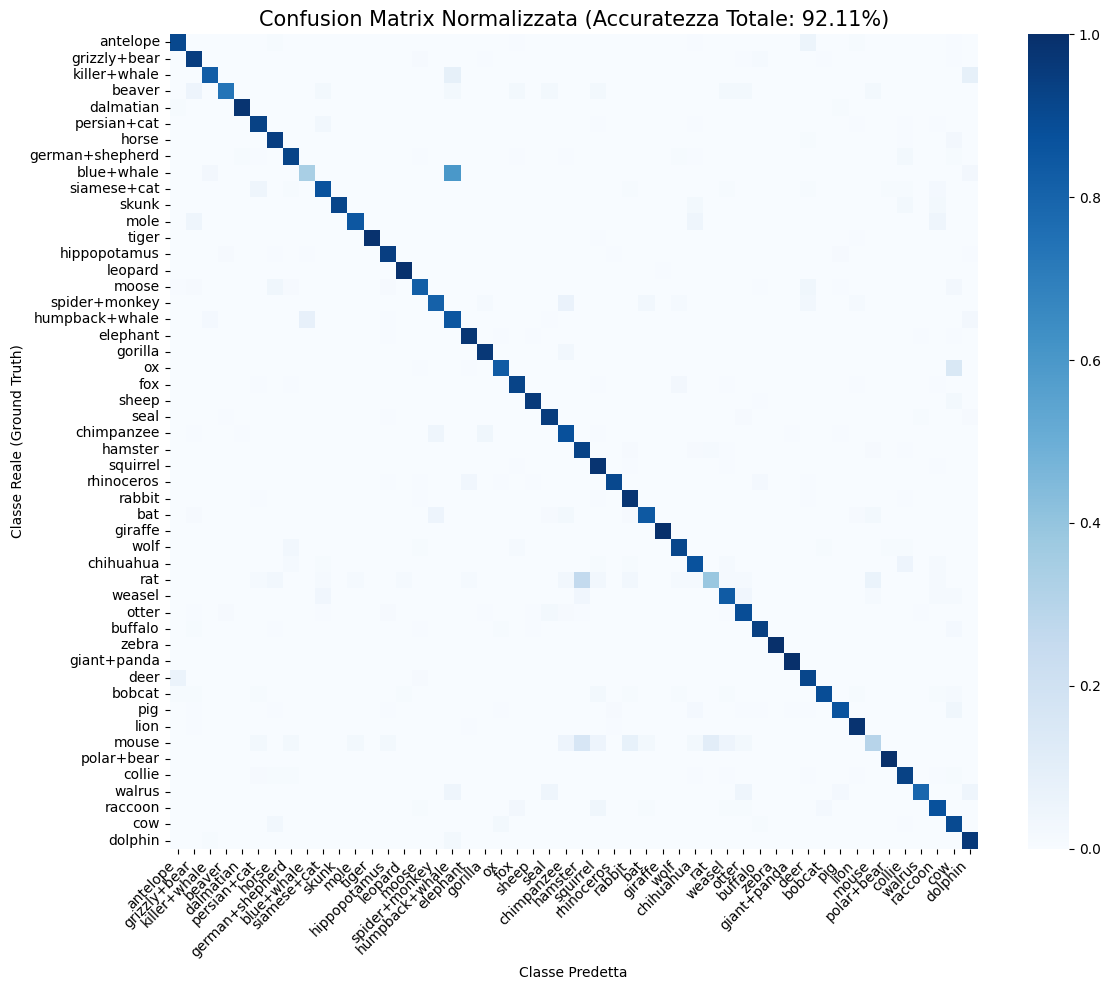


Analisi degli Errori Principali:
 - 22 volte: 'ox' è stato scambiato per 'cow'
 - 21 volte: 'blue+whale' è stato scambiato per 'humpback+whale'
 - 16 volte: 'deer' è stato scambiato per 'antelope'
 - 16 volte: 'rat' è stato scambiato per 'hamster'
 - 12 volte: 'humpback+whale' è stato scambiato per 'blue+whale'


In [33]:
plot_test_results(b_accuracy, b_preds, b_labels, class_names=classes)

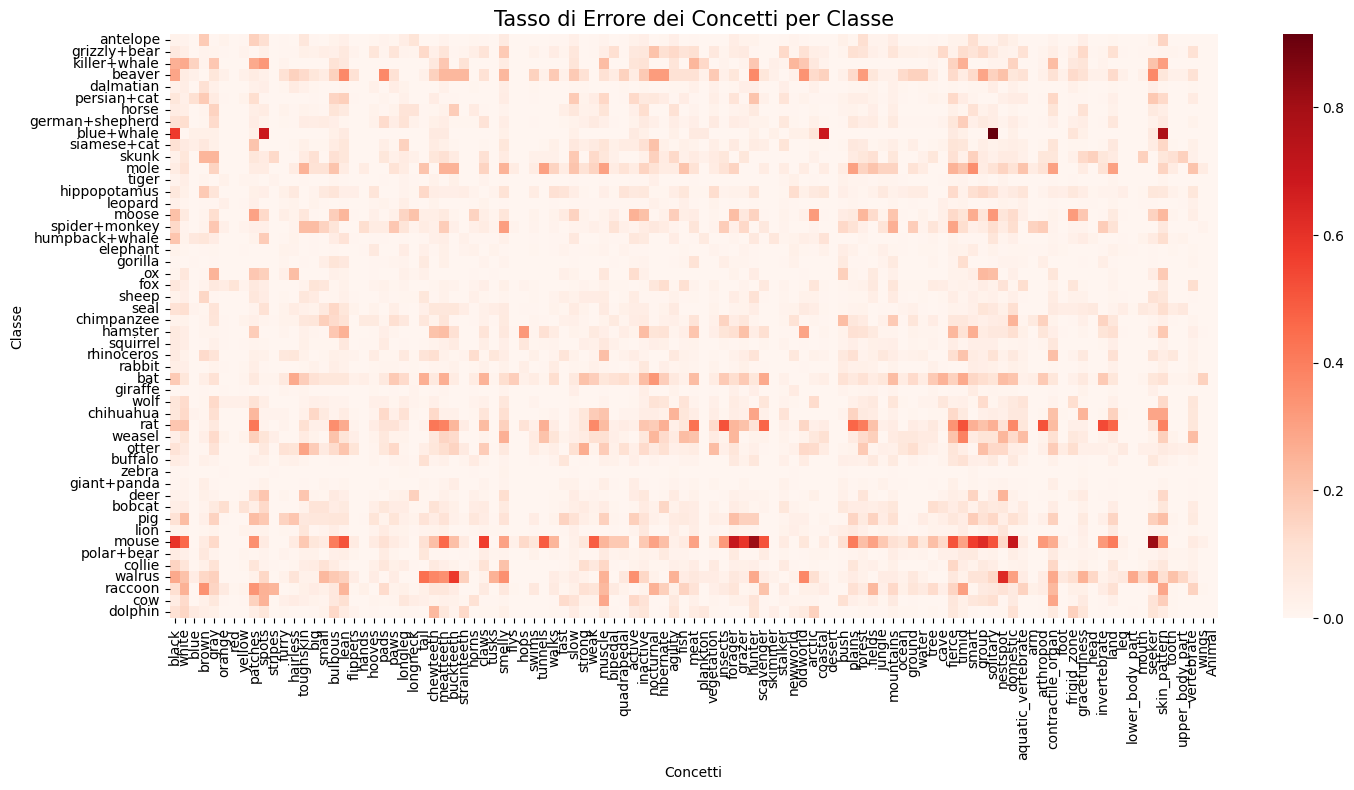

In [30]:
plot_concept_error_heatmap(labels,b_concepts_preds, b_concepts_truth, classes, concepts)

In [ ]:
analyze_misclassifications_concepts(b_preds, b_labels, b_concepts_preds, b_concepts_truth, classes, concepts, num_examples=10)

In [ ]:
plot_concept_uncertainty_heatmap(labels, b_concepts_probs, class_names=classes, concept_names=concepts)

#### TEST TIME INTERVENTION

In [ ]:
from src.utils.plot import plot_intervention_curve
plot_intervention_curve(
    k_values=[0,1,2,3,4,5,10,20,25,30],
    model=b_model,
    test_loader=test_dataloader,
    class_concept_matrix=class_concept_matrix,
    boxes_tensor=box_tensors,
    device=device,
    info=info,
    concept_predictor=concept_predictor
)

### RELATION MATRIX

In [35]:
info = "rel_matrix"
cp_accuracy, cp_preds, cp_labels, cp_concepts_preds, cp_concepts_truth, cp_concepts_probs = test_cbm_classifier(
     model=cp_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 83.54%


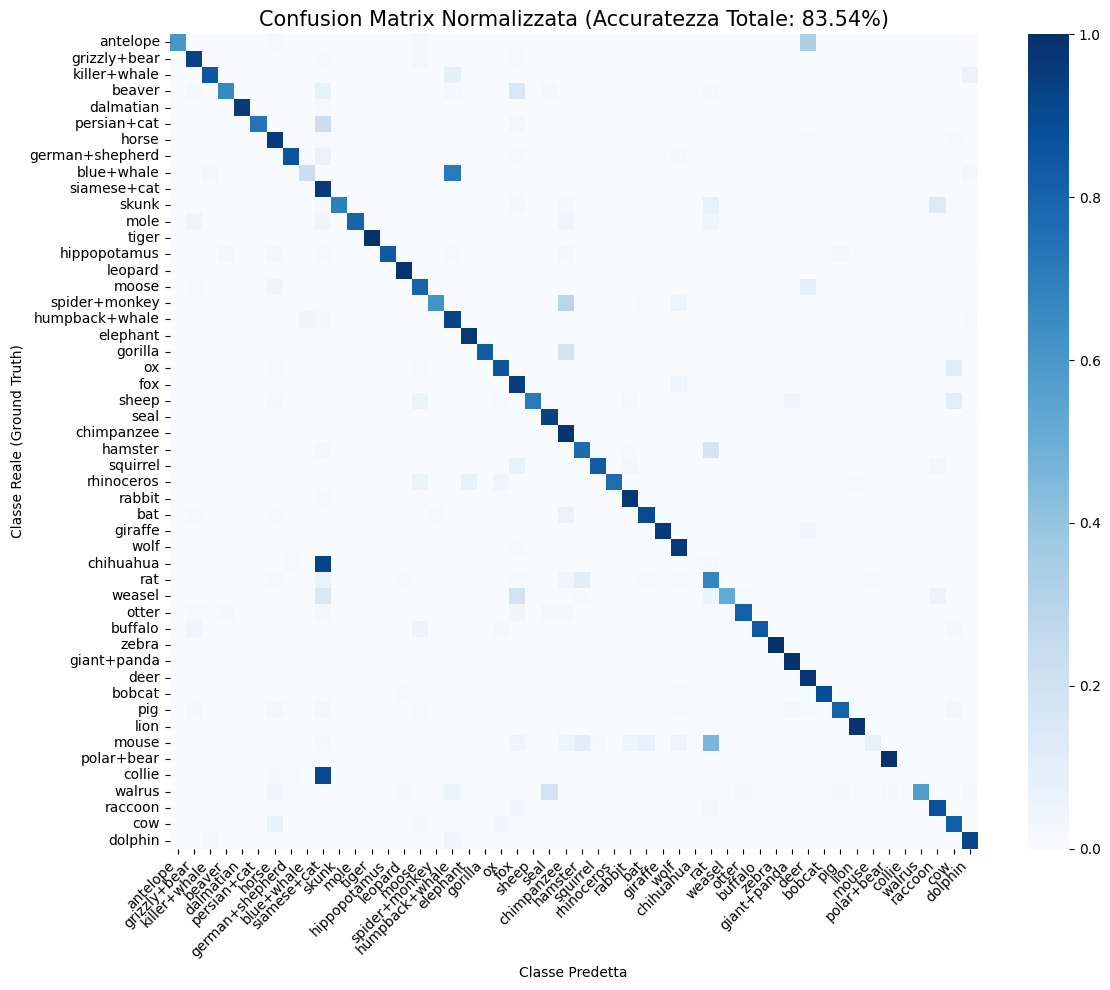


Analisi degli Errori Principali:
 - 188 volte: 'collie' è stato scambiato per 'siamese+cat'
 - 105 volte: 'chihuahua' è stato scambiato per 'siamese+cat'
 - 70 volte: 'antelope' è stato scambiato per 'deer'
 - 34 volte: 'persian+cat' è stato scambiato per 'siamese+cat'
 - 31 volte: 'gorilla' è stato scambiato per 'chimpanzee'


In [36]:
plot_test_results(cp_accuracy, cp_preds, cp_labels, class_names=classes)

### STANDARD CBM

In [32]:
info = "concepts"
c_accuracy, c_preds, c_labels, b_concepts_preds, b_concepts_truth, b_concepts_probs = test_cbm_classifier(
     model=c_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 91.80%


In [ ]:
plot_test_results(c_accuracy, c_preds, c_labels, class_names=classes)